Dataset shape: (19959, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.24     37.85                52.0       1467.0           190.0   
1    -122.25     37.85                52.0       1274.0           235.0   
2    -122.25     37.85                52.0       1627.0           280.0   
3    -122.25     37.85                52.0        919.0           213.0   
4    -122.25     37.84                52.0       2535.0           489.0   

   population  households  median_income  median_house_value ocean_proximity  
0       496.0       177.0         7.2574            352100.0        NEAR BAY  
1       558.0       219.0         5.6431            341300.0        NEAR BAY  
2       565.0       259.0         3.8462            342200.0        NEAR BAY  
3       413.0       193.0         4.0368            269700.0        NEAR BAY  
4      1094.0       514.0         3.6591            299200.0        NEAR BAY  
Encoded dataset shape: (19959, 13)
Train shape: 

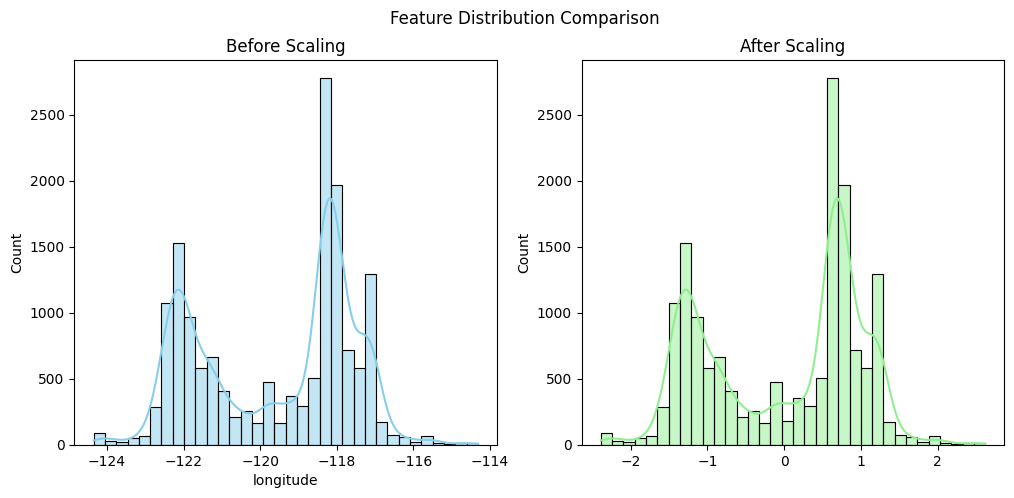

Means after scaling: [ 5.17988191e-16 -2.73946332e-15 -1.20596907e-16 -8.18812948e-17
  7.29811540e-17]
Std devs after scaling: [1. 1. 1. 1. 1.]
Final prepared dataset saved as final_prepared.csv


In [5]:
# --- Step 1: Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Step 2: Load cleaned dataset ---
df = pd.read_csv("../data/cleaned_housing.csv")
print("Dataset shape:", df.shape)
print(df.head())

# --- Step 3: Encode categorical column ---
df_encoded = pd.get_dummies(df, drop_first=True)
print("Encoded dataset shape:", df_encoded.shape)

# --- Step 4: Split into train/test ---
X = df_encoded.drop("median_house_value", axis=1)
y = df_encoded["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# --- Step 5: Scale features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
# Compare distributions before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(X_train.iloc[:, 0], ax=axes[0], kde=True, color='skyblue')
axes[0].set_title("Before Scaling")

sns.histplot(X_train_scaled[:, 0], ax=axes[1], kde=True, color='lightgreen')
axes[1].set_title("After Scaling")

plt.suptitle("Feature Distribution Comparison")
plt.show()

# --- Step 6: Save final dataset ---
final_df = pd.DataFrame(X_train_scaled, columns=X.columns)
final_df["median_house_value"] = y_train.values
final_df.to_csv("../data/final_prepared.csv", index=False)

print("Means after scaling:", np.mean(X_train_scaled, axis=0)[:5])
print("Std devs after scaling:", np.std(X_train_scaled, axis=0)[:5])

print("Final prepared dataset saved as final_prepared.csv")

